# EDA: пассажиропоток линии 7 MTA, 2023–2024

Этап 2. Данные — `data/interim/` (после `python -m src.download && python -m src.clean`).
Расчёты — в `src/eda.py`; здесь только вызовы, графики (сохраняются в `reports/figures/`) и одна строка вывода с цифрами под каждым графиком.

- Строки с `dst_flag != ""` исключены при загрузке (CLAUDE.md).
- Тип дня: будни / суббота / воскресенье / праздник (федеральный выходной).
- Группы станций (не пересекаются): Манхэттен (4), пересадочные Квинса (3: 74 St, Queensboro Plaza, Court Sq), остальные Квинса (15).
- Рабочие часы для шума и погоды — 06:00–23:59 местного времени.

Выводы и решения для этапа признаков — `docs/eda_findings.md`.

In [1]:
import sys
from pathlib import Path

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from matplotlib.lines import Line2D
from matplotlib.ticker import MultipleLocator, PercentFormatter

from src import eda

eda.style()
PCT = PercentFormatter(1.0, decimals=0)
MONTHS = ["янв", "фев", "мар", "апр", "май", "июн", "июл", "авг", "сен", "окт", "ноя", "дек"]
short = lambda name: name.split(" (")[0]

d = eda.load()
st = d.stations.set_index("station_id")
print(f"Строк MTA без DST-часов: {len(d.mta):,}; станций: {d.mta.station_id.nunique()}; группы: "
      + ", ".join(f"{g} — {n}" for g, n in d.stations.group.value_counts().reindex(eda.GROUPS).items()))

Строк MTA без DST-часов: 385,880; станций: 22; группы: Манхэттен — 4, Пересадочные Квинса — 3, Остальные Квинса — 15


## 1. Суточные профили

Доля суточных входов по часам — по группам станций и типам дня. Где утренний пик (06–10) сильнее вечернего (16–20) и во сколько раз.

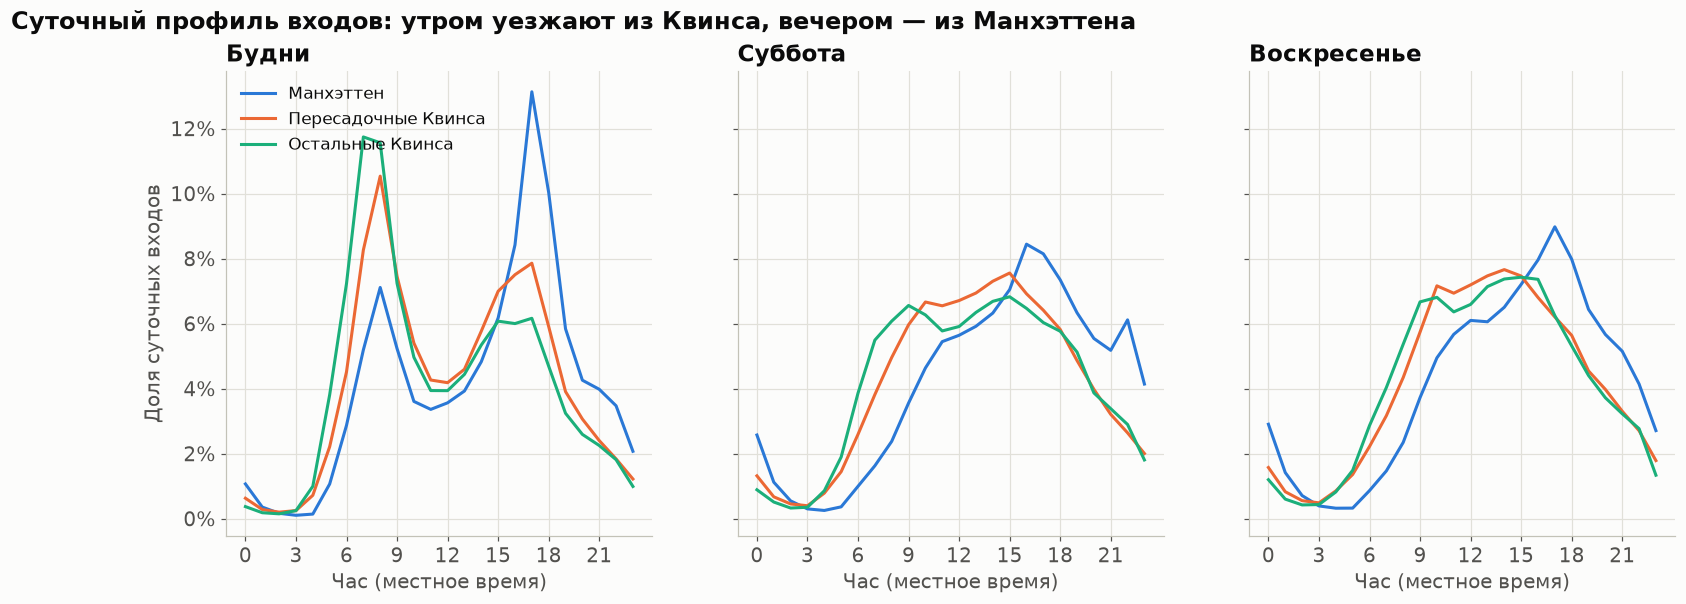

Будни: утренний пик сильнее вечернего у 14 из 22 станций, из них в Квинсе — 14; утро/вечер: остальные Квинса ×1.90, пересадочные Квинса ×1.34, в Манхэттене вечер сильнее утра в 1.85 раза; в выходные у станций Квинса пики почти равны (×0.92–1.05).


In [2]:
prof = eda.daily_profiles(d.mta)
fig, axes = plt.subplots(1, 3, figsize=(17, 5.5), sharey=True)
for ax, dt in zip(axes, ["будни", "суббота", "воскресенье"]):
    for grp in eda.GROUPS:
        p = prof[(prof.group == grp) & (prof.day_type == dt)]
        ax.plot(p.hour, p.share, color=eda.GROUP_COLORS[grp], label=grp)
    ax.set_title(dt.capitalize(), loc="left")
    ax.set_xticks(range(0, 24, 3))
    ax.set_xlabel("Час (местное время)")
    ax.yaxis.set_major_formatter(PCT)
axes[0].set_ylabel("Доля суточных входов")
axes[0].legend(loc="upper left")
fig.suptitle("Суточный профиль входов: утром уезжают из Квинса, вечером — из Манхэттена",
             x=0.01, ha="left", fontsize=16, fontweight="bold")
eda.save(fig, "01_daily_profiles")
plt.show()

grp_r = eda.peak_ratios(d.mta, "group")
wd = grp_r[grp_r.day_type == "будни"].set_index("group").ratio
we = grp_r[(grp_r.day_type != "будни") & (grp_r.group != "Манхэттен")].ratio
sr = eda.peak_ratios(d.mta).query("day_type == 'будни'")
morning = sr[sr.ratio > 1].station_id
print(f"Будни: утренний пик сильнее вечернего у {len(morning)} из 22 станций, из них в Квинсе — {(st.loc[morning, 'borough'] == 'Queens').sum()}; "
      f"утро/вечер: остальные Квинса ×{wd['Остальные Квинса']:.2f}, пересадочные Квинса ×{wd['Пересадочные Квинса']:.2f}, "
      f"в Манхэттене вечер сильнее утра в {1 / wd['Манхэттен']:.2f} раза; в выходные у станций Квинса пики почти равны (×{we.min():.2f}–{we.max():.2f}).")

## 2. Недельная сезонность

Автокорреляция часового ряда с лагом 168 ч («тот же час неделю назад») по каждой станции; лаг 24 ч — для сравнения.

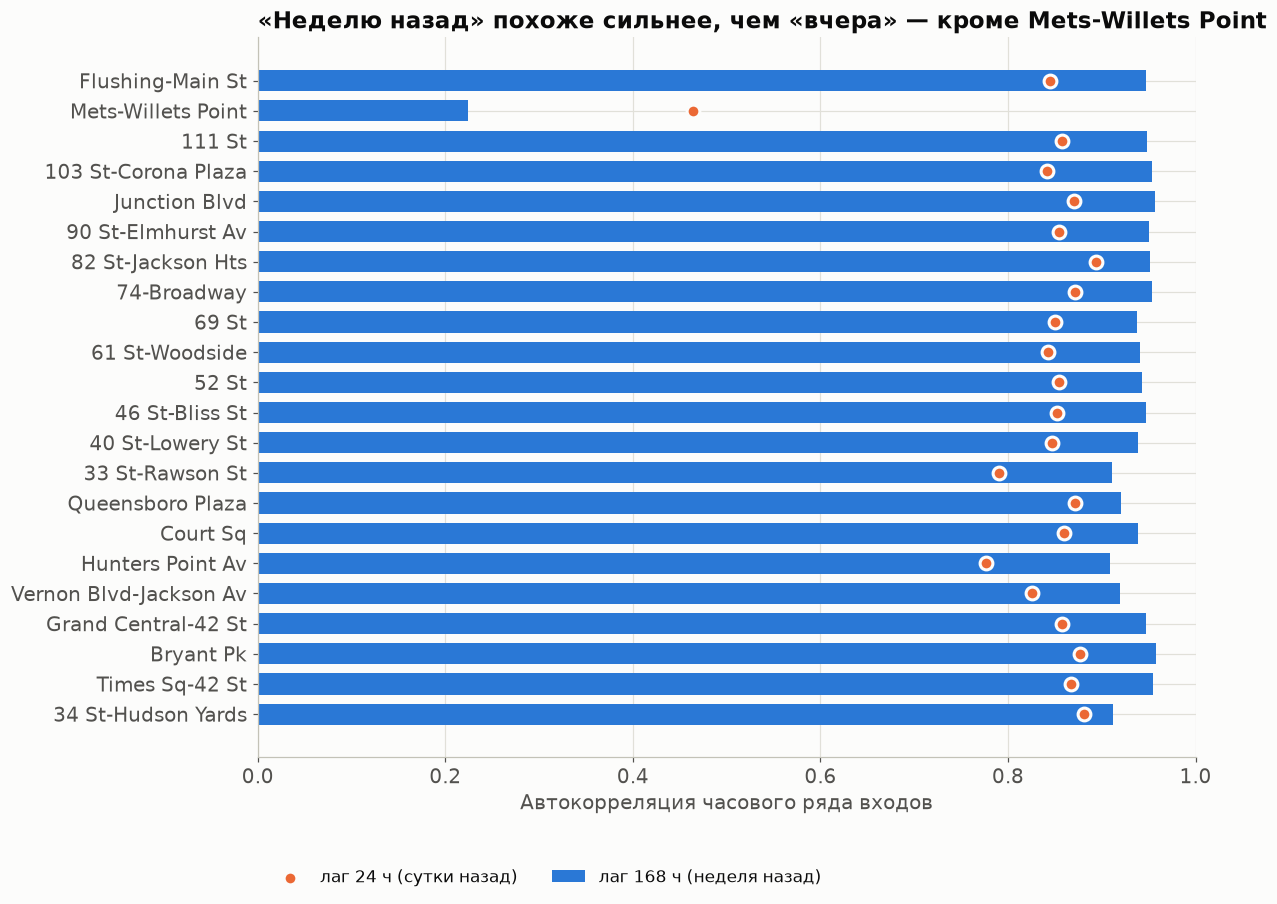

Лаг 168 ч: медиана 0.945, у остальных станций (21) — 0.91…0.96; выше лага 24 ч у 21 из 22 (медиана лага 24 ч 0.854); у Mets-Willets Point всего 0.22: поток там задают матчи и US Open, а не неделя.


In [3]:
ac = eda.weekly_autocorr(d.mta, d.stations)
fig, ax = plt.subplots(figsize=(11, 8.5))
y = np.arange(len(ac))
ax.barh(y, ac.lag_168, height=0.7, color=eda.SERIES[0], label="лаг 168 ч (неделя назад)")
ax.scatter(ac.lag_24, y, s=70, color=eda.SERIES[1], edgecolor=eda.SURFACE, linewidth=2, zorder=3, label="лаг 24 ч (сутки назад)")
ax.set_yticks(y, [short(n) for n in ac.name])
ax.invert_yaxis()
ax.set_xlim(0, 1)
ax.set_xlabel("Автокорреляция часового ряда входов")
ax.set_title("«Неделю назад» похоже сильнее, чем «вчера» — кроме Mets-Willets Point", loc="left")
ax.legend(loc="lower left", bbox_to_anchor=(0, -0.2), ncol=2)
eda.save(fig, "02_weekly_autocorr")
plt.show()

a = ac.set_index("station_id")
rest = a.drop("448")
print(f"Лаг 168 ч: медиана {ac.lag_168.median():.3f}, у остальных станций ({len(rest)}) — {rest.lag_168.min():.2f}…{rest.lag_168.max():.2f}; "
      f"выше лага 24 ч у {(ac.lag_168 > ac.lag_24).sum()} из 22 (медиана лага 24 ч {ac.lag_24.median():.3f}); "
      f"у Mets-Willets Point всего {a.lag_168['448']:.2f}: поток там задают матчи и US Open, а не неделя.")

## 3. Тренд 2023 → 2024

Средний суточный поток будних дней по месяцам (не зависит от длины месяца и числа выходных) и прирост год к году.

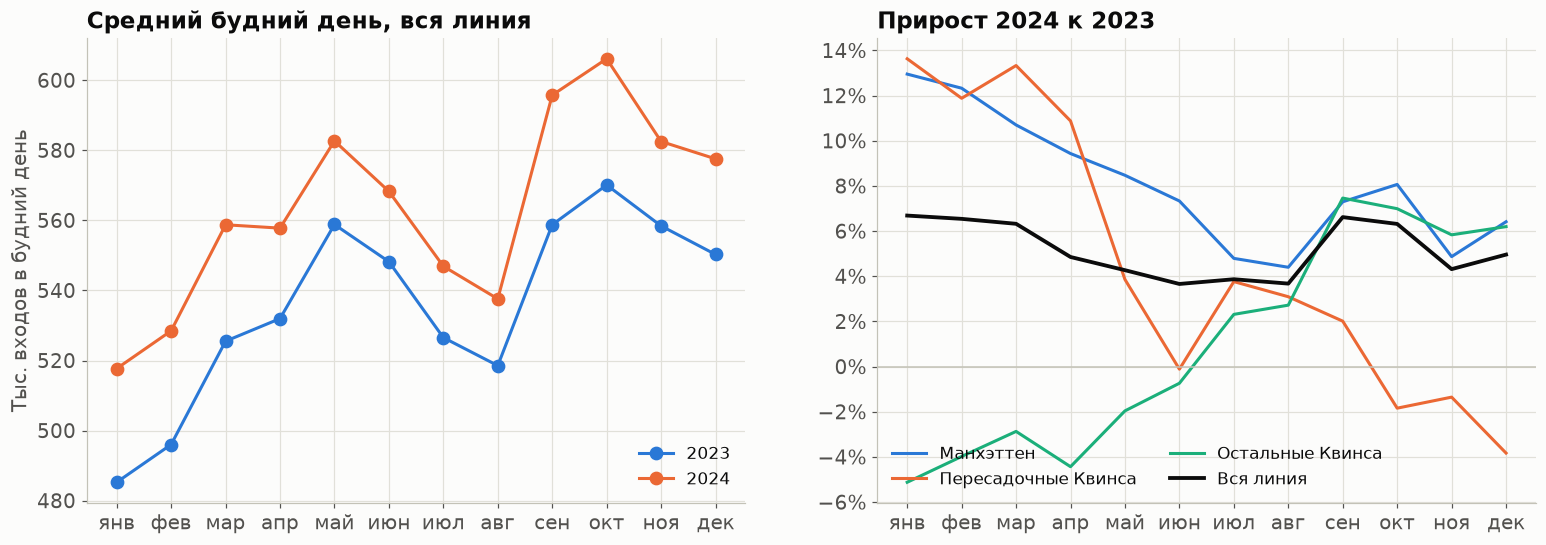

Будни 2024 к 2023: +5.2% в среднем (I полугодие +5.4%, II полугодие +5.0%, декабрь +5.0%) — восстановление продолжается, плато не видно; в пропусках потеряно 0.11% потока.


In [4]:
tr = eda.monthly_trend(d.mta)
line = tr[tr.level == "Вся линия"].set_index("month")
fig, (a1, a2) = plt.subplots(1, 2, figsize=(17, 5.5))
for yr, c in ((2023, eda.SERIES[0]), (2024, eda.SERIES[1])):
    a1.plot(line.index, line[yr] / 1000, marker="o", color=c, label=str(yr))
a1.set_xticks(range(1, 13), MONTHS)
a1.set_ylabel("Тыс. входов в будний день")
a1.set_title("Средний будний день, вся линия", loc="left")
a1.legend(loc="lower right")
for lvl in eda.GROUPS:
    g = tr[tr.level == lvl]
    a2.plot(g.month, g.yoy, color=eda.GROUP_COLORS[lvl], label=lvl)
a2.plot(line.index, line.yoy, color=eda.INK, linewidth=2.5, label="Вся линия")
a2.axhline(0, color=eda.AXIS, linewidth=1)
a2.set_xticks(range(1, 13), MONTHS)
a2.yaxis.set_major_locator(MultipleLocator(0.02))
a2.yaxis.set_major_formatter(PCT)
a2.set_title("Прирост 2024 к 2023", loc="left")
a2.legend(loc="lower left", ncol=2)
eda.save(fig, "03_monthly_trend")
plt.show()

h1, h2 = line.loc[1:6, "yoy"].mean(), line.loc[7:12, "yoy"].mean()
verdict = "восстановление продолжается, плато не видно" if h2 > 0.02 else "рост почти остановился — похоже на плато"
print(f"Будни 2024 к 2023: +{line.yoy.mean():.1%} в среднем (I полугодие +{h1:.1%}, II полугодие +{h2:.1%}, декабрь +{line.yoy[12]:.1%}) — {verdict}; "
      f"в пропусках потеряно {eda.missing_volume_share(d.mta):.2%} потока.")

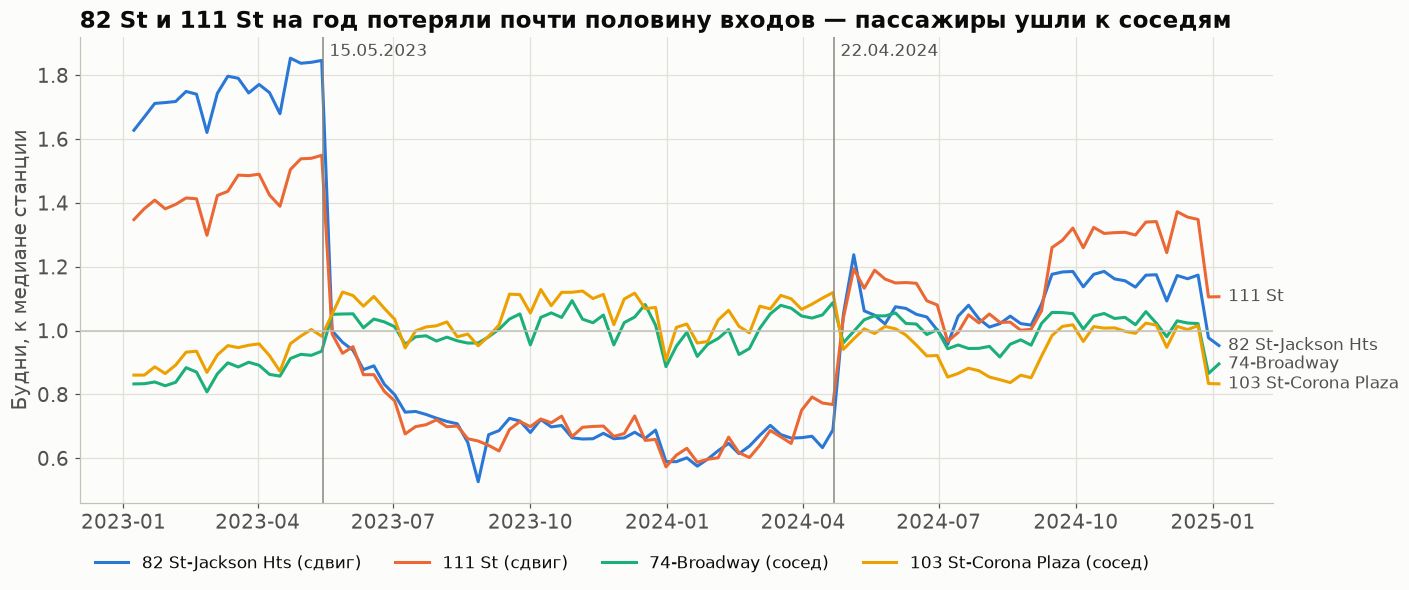

Смена уровня 15.05.2023: 82 St -47%, 111 St -38%, соседи 74 St +13% и 103 St +9%; 22.04.2024: 82 St +73%, 111 St +45%, 74 St -8%, 103 St -14%; на всю линию +0.4% и -1.0% — поток перераспределился между станциями, а не пропал. Из-за этого прирост по группам в п. 3 зеркальный, а по всей линии — нет.


In [5]:
ids = list(eda.LEVEL_SHIFT_STATIONS)
wl = eda.weekly_level(d.mta, ids)
steps = eda.level_steps(d.mta)
fig, ax = plt.subplots(figsize=(14, 5.5))
colors = dict(zip(ids, eda.SERIES + ["#eda100"]))
for sid in ids:
    ax.plot(wl.index, wl[sid], color=colors[sid], label=f"{short(st.at[sid, 'name'])} ({eda.LEVEL_SHIFT_STATIONS[sid]})")
    ax.annotate(short(st.at[sid, "name"]), (wl.index[-1], wl[sid].iloc[-1]), xytext=(6, 0), textcoords="offset points",
                color=eda.INK2, fontsize=11, va="center")
for dt in eda.LEVEL_SHIFT_DATES:
    ax.axvline(dt, color=eda.MUTED, linewidth=1)
    ax.annotate(dt.strftime("%d.%m.%Y"), (dt, ax.get_ylim()[1]), xytext=(4, -4), textcoords="offset points",
                color=eda.INK2, fontsize=11, va="top")
ax.axhline(1, color=eda.AXIS, linewidth=1)
ax.set_ylabel("Будни, к медиане станции")
ax.set_title("82 St и 111 St на год потеряли почти половину входов — пассажиры ушли к соседям", loc="left")
ax.legend(loc="upper left", bbox_to_anchor=(0, -0.08), ncol=4)
eda.save(fig, "03_station_level_shifts")
plt.show()

s1, s2 = steps.iloc[0], steps.iloc[1]
print(f"Смена уровня {eda.LEVEL_SHIFT_DATES[0]:%d.%m.%Y}: 82 St {s1['453']:+.0%}, 111 St {s1['449']:+.0%}, соседи 74 St {s1['616']:+.0%} и 103 St {s1['450']:+.0%}; "
      f"{eda.LEVEL_SHIFT_DATES[1]:%d.%m.%Y}: 82 St {s2['453']:+.0%}, 111 St {s2['449']:+.0%}, 74 St {s2['616']:+.0%}, 103 St {s2['450']:+.0%}; "
      f"на всю линию {s1['вся линия']:+.1%} и {s2['вся линия']:+.1%} — поток перераспределился между станциями, а не пропал. "
      f"Из-за этого прирост по группам в п. 3 зеркальный, а по всей линии — нет.")

## 4. Праздники

Суточный поток линии в праздник против обычных будней той же недели (если в неделе ≥ 2 обычных будних дня;
для праздников в выходные и «пустых» недель — против того же дня недели ±1 и ±2 недели). Точка — сравнение с тем же днём недели для всех.
Категории из `holidays_us` (одна на дату: федеральные > штат NY > неофициальные) плюс пред- и послепраздничные рабочие дни.

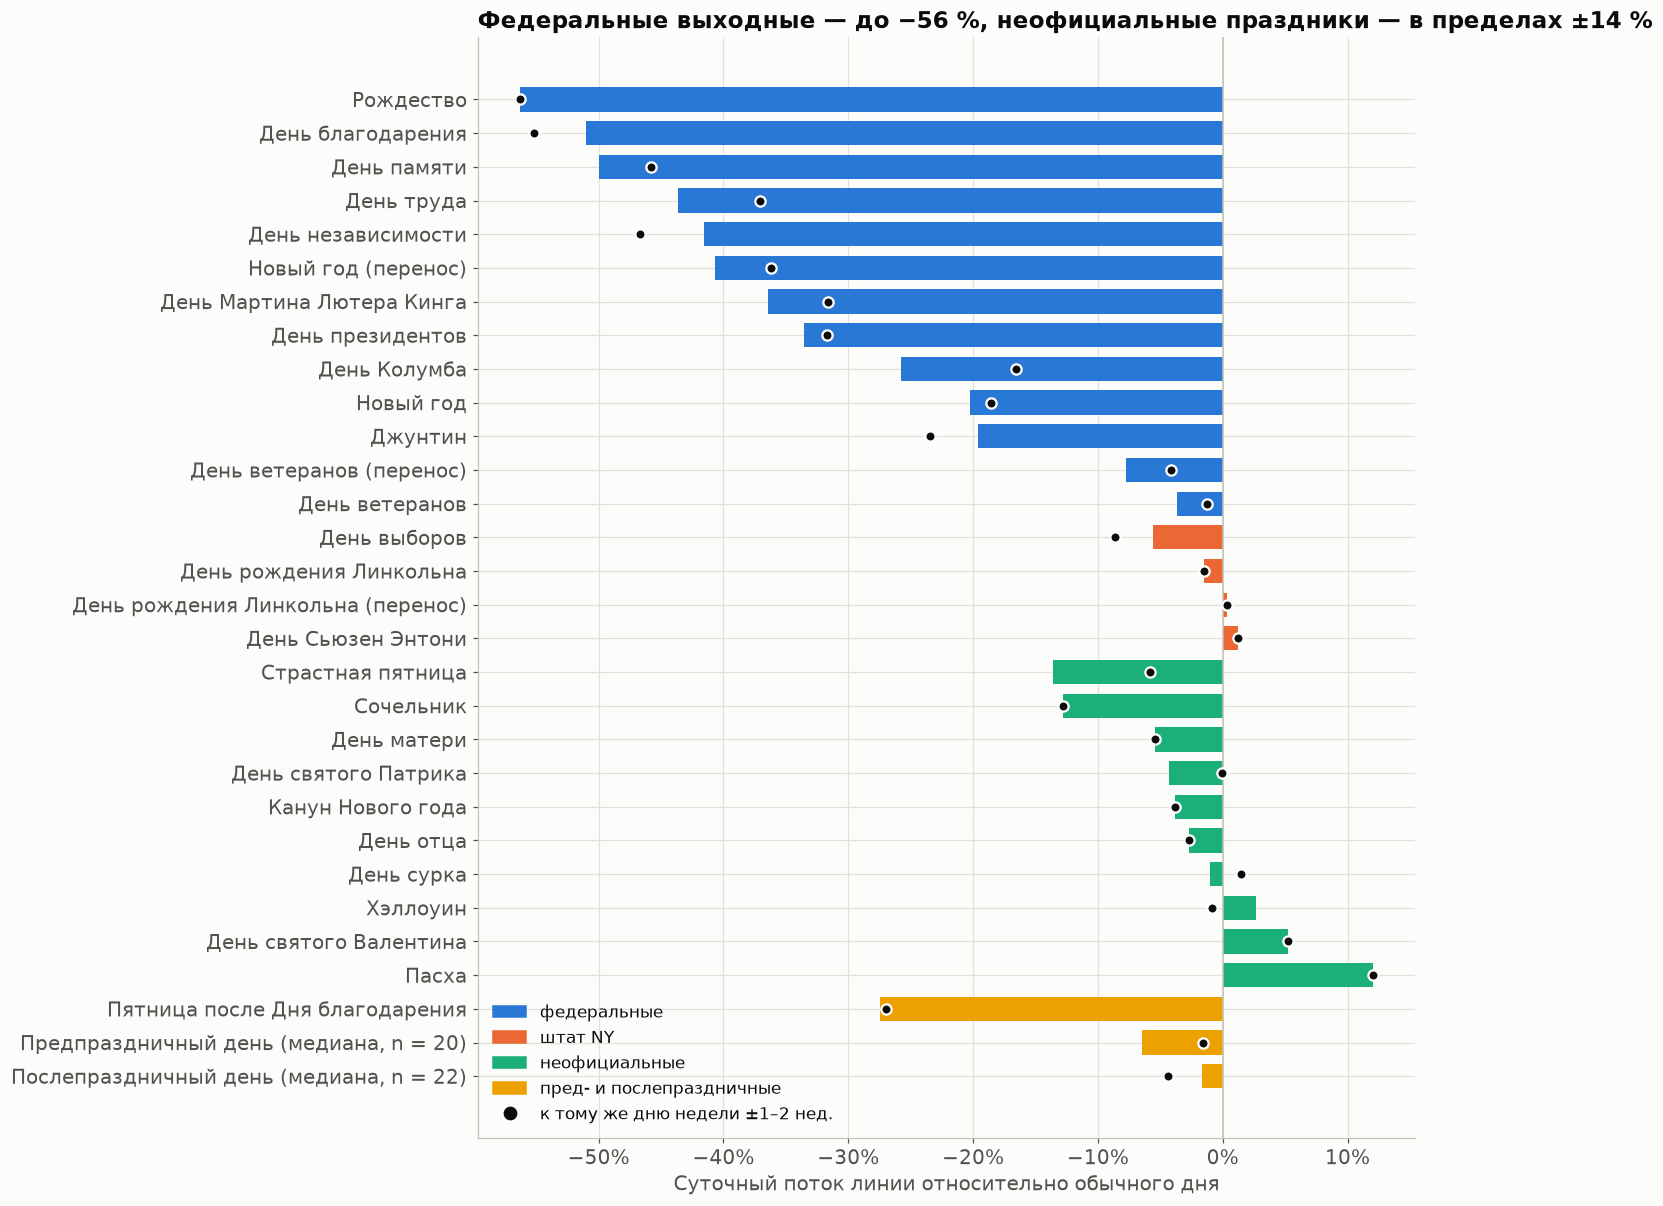

Федеральные: -39% к будням той же недели и -35% к тому же дню недели (сильнее всего Рождество -56% и День благодарения -55%); штат NY +0.3%, неофициальные -0.9%; предпраздничный день -7.4% к той же неделе, но -1.6% к тому же дню недели — это «эффект пятницы» (пн -10%, пт -10% к вт–чт); пятница после Дня благодарения -27%.


In [6]:
he = eda.holiday_effects(d.mta, d.holidays)
he["name_ru"] = he.name.map(eda.holiday_ru)
main = he[he.category.isin(["public", "ny_public", "unofficial"])]
by_name = (main.groupby(["category", "name_ru"]).agg(effect=("effect", "mean"), eff_adj=("eff_adj", "mean")).reset_index())
pp = he[he.category.isin(["предпраздничный", "послепраздничный"])]
bf = pp[(pp.category == "послепраздничный") & pp.name.str.contains("Thanksgiving")]
extra = pd.DataFrame([
    {"category": c, "name_ru": f"{eda.CATEGORY_RU[c].capitalize()} (медиана, n = {len(g)})",
     "effect": g.effect.median(), "eff_adj": g.eff_adj.median()} for c, g in pp.groupby("category")
] + [{"category": "послепраздничный", "name_ru": "Пятница после Дня благодарения", "effect": bf.effect.mean(), "eff_adj": bf.eff_adj.mean()}])
order = {"public": 0, "ny_public": 1, "unofficial": 2, "предпраздничный": 3, "послепраздничный": 3}
rows = pd.concat([by_name, extra]).assign(o=lambda t: t.category.map(order)).sort_values(["o", "effect"]).reset_index(drop=True)
cat_color = {"public": eda.SERIES[0], "ny_public": eda.SERIES[1], "unofficial": eda.SERIES[2],
             "предпраздничный": "#eda100", "послепраздничный": "#eda100"}

fig, ax = plt.subplots(figsize=(11, 13))
y = np.arange(len(rows))
ax.barh(y, rows.effect, height=0.72, color=rows.category.map(cat_color))
ax.scatter(rows.eff_adj, y, s=45, color=eda.INK, edgecolor=eda.SURFACE, linewidth=1.5, zorder=3)
ax.set_yticks(y, rows.name_ru)
ax.invert_yaxis()
ax.axvline(0, color=eda.AXIS, linewidth=1)
ax.xaxis.set_major_formatter(PCT)
ax.set_xlabel("Суточный поток линии относительно обычного дня")
ax.set_title("Федеральные выходные — до −56 %, неофициальные праздники — в пределах ±14 %", loc="left")
handles = [Patch(color=cat_color[c], label=eda.CATEGORY_RU[c]) for c in ["public", "ny_public", "unofficial"]]
handles += [Patch(color="#eda100", label="пред- и послепраздничные"),
            Line2D([], [], marker="o", linestyle="", color=eda.INK, label="к тому же дню недели ±1–2 нед.")]
ax.legend(handles=handles, loc="lower left")
eda.save(fig, "04_holidays")
plt.show()

cat = he.groupby("category")[["eff_week", "eff_adj"]].median()
lvl = eda.weekday_levels(d.mta, d.holidays)
top = by_name[by_name.category == "public"].nsmallest(2, "eff_adj")
print(f"Федеральные: {cat.loc['public', 'eff_week']:+.0%} к будням той же недели и {cat.loc['public', 'eff_adj']:+.0%} к тому же дню недели "
      f"(сильнее всего {top.name_ru.iloc[0]} {top.eff_adj.iloc[0]:+.0%} и {top.name_ru.iloc[1]} {top.eff_adj.iloc[1]:+.0%}); "
      f"штат NY {cat.loc['ny_public', 'eff_adj']:+.1%}, неофициальные {cat.loc['unofficial', 'eff_adj']:+.1%}; "
      f"предпраздничный день {cat.loc['предпраздничный', 'eff_week']:+.1%} к той же неделе, но {cat.loc['предпраздничный', 'eff_adj']:+.1%} к тому же дню недели — "
      f"это «эффект пятницы» (пн {lvl[0]:+.0%}, пт {lvl[4]:+.0%} к вт–чт); пятница после Дня благодарения {bf.eff_adj.mean():+.0%}.")

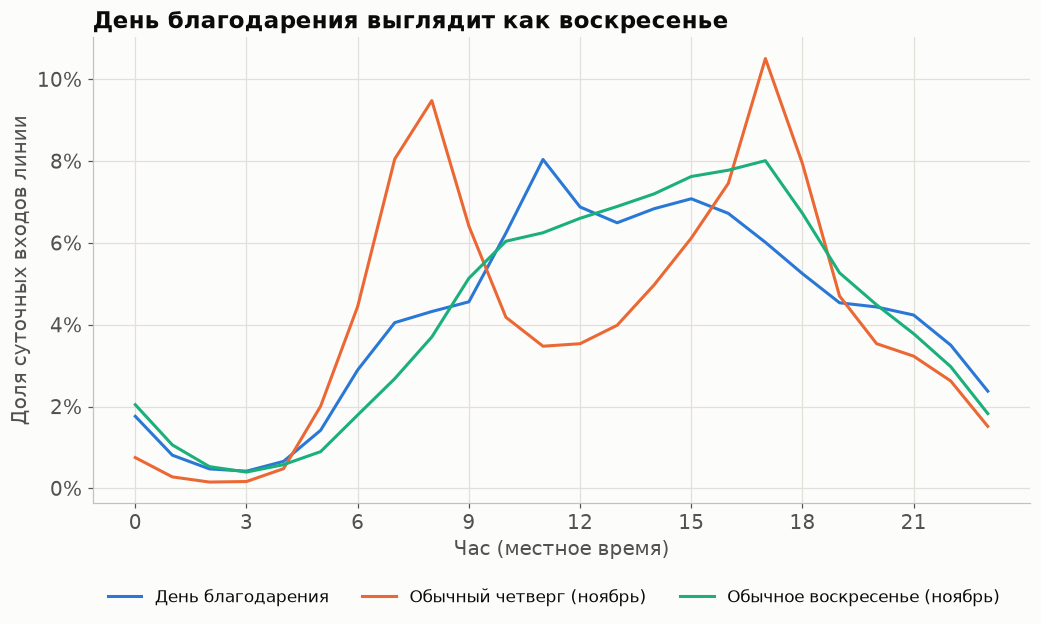

В День благодарения утренний пик пропадает: доля 07–09 ч 12.9% против 23.9% в обычный четверг и 11.5% в воскресенье; корреляция профиля с воскресным 0.95, с будничным 0.64.


In [7]:
hp = eda.holiday_profile(d.mta, d.holidays, "Thanksgiving Day")
labels = {"Thanksgiving Day": "День благодарения", "обычный тот же день недели": "Обычный четверг (ноябрь)",
          "обычное воскресенье": "Обычное воскресенье (ноябрь)"}
fig, ax = plt.subplots(figsize=(11, 5.5))
for (col, lab), c in zip(labels.items(), eda.SERIES):
    ax.plot(hp.index, hp[col], color=c, label=lab)
ax.set_xticks(range(0, 24, 3))
ax.set_xlabel("Час (местное время)")
ax.set_ylabel("Доля суточных входов линии")
ax.yaxis.set_major_formatter(PCT)
ax.set_title("День благодарения выглядит как воскресенье", loc="left")
ax.legend(loc="upper left", bbox_to_anchor=(0, -0.15), ncol=3)
eda.save(fig, "04_thanksgiving_profile")
plt.show()

m = hp.loc[7:9].sum()
r = hp.corr()["Thanksgiving Day"]
print(f"В День благодарения утренний пик пропадает: доля 07–09 ч {m['Thanksgiving Day']:.1%} против {m['обычный тот же день недели']:.1%} в обычный четверг "
      f"и {m['обычное воскресенье']:.1%} в воскресенье; корреляция профиля с воскресным {r['обычное воскресенье']:.2f}, с будничным {r['обычный тот же день недели']:.2f}.")

## 5. Погода

Поток в часы с дождём и снегом (архив Open-Meteo, факт) против среднего сухих часов той же ячейки
«станция × час × тип дня × месяц» (месяц — чтобы снег не смешался с зимним сезоном). Эффект = Σ входов / Σ сухой нормы − 1,
95 % интервал — бутстреп по дням. Рабочие часы, без праздников. Те же расчёты с флагами из исторического прогноза — для оценки, что останется в признаках.

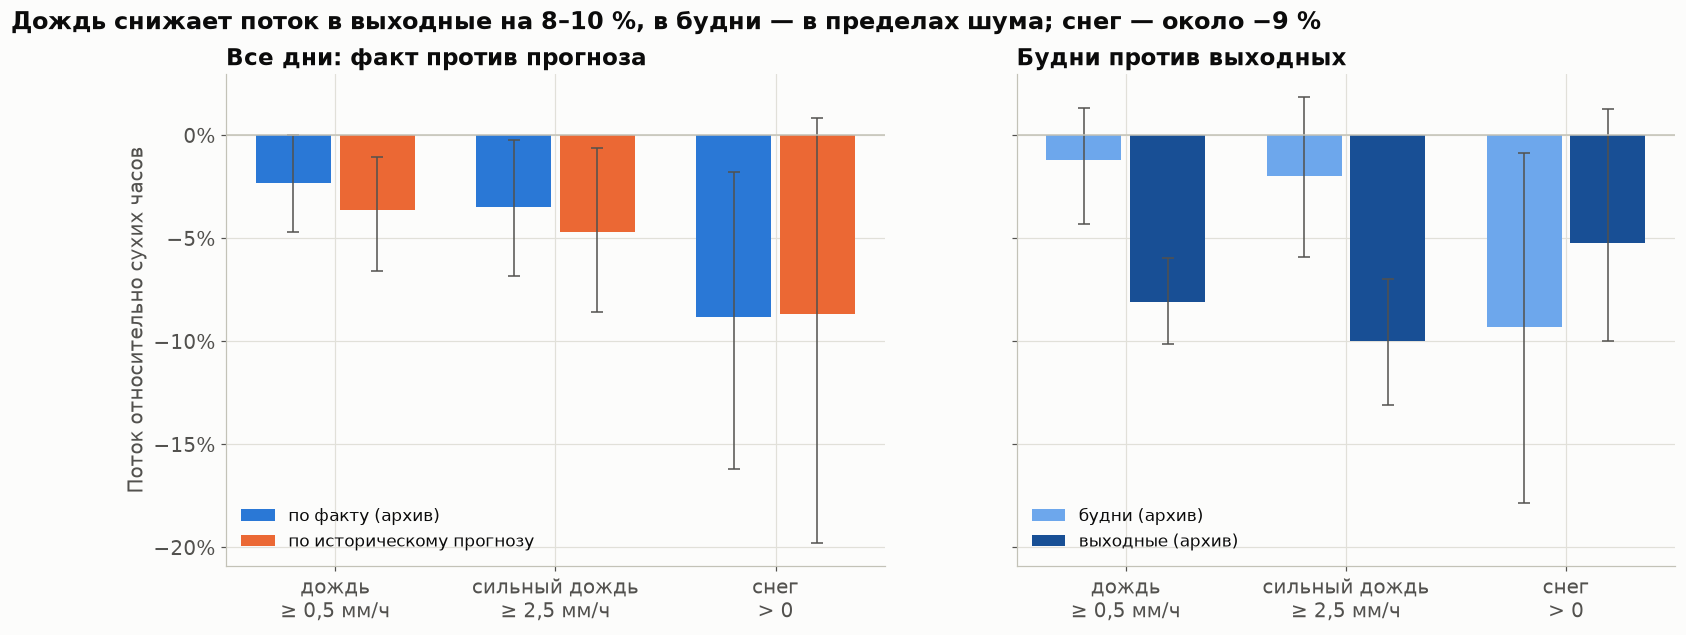

По факту: дождь ≥ 0,5 мм/ч -2.3% (95 % ДИ -4.7%…+0.0%), в выходные -8.1%, в будни -1.2% (ДИ включает 0); сильный дождь в выходные -10.0%; снег -8.8% (ДИ -16.2%…-1.8%, 30 дней).


In [8]:
wa = eda.weather_effect(d.mta, eda.weather_flags(d.weather))
wf = eda.weather_effect(d.mta, eda.weather_flags(d.forecast))
cats = list(eda.WEATHER_CATS)
x = np.arange(len(cats))
fig, (a1, a2) = plt.subplots(1, 2, figsize=(17, 5.8), sharey=True)
for i, (lab, df, c) in enumerate((("по факту (архив)", wa, eda.SERIES[0]), ("по историческому прогнозу", wf, eda.SERIES[1]))):
    s = df[df.segment == "все дни"].set_index("cat").loc[cats]
    a1.bar(x + (i - 0.5) * 0.38, s.effect, width=0.34, color=c, label=lab,
           yerr=[s.effect - s.lo, s.hi - s.effect], capsize=4, error_kw={"ecolor": eda.INK2, "elinewidth": 1})
for i, (seg, c) in enumerate((("будни", eda.BLUE_RAMP[2]), ("выходные", eda.BLUE_RAMP[5]))):
    s = wa[wa.segment == seg].set_index("cat").loc[cats]
    a2.bar(x + (i - 0.5) * 0.38, s.effect, width=0.34, color=c, label=f"{seg} (архив)",
           yerr=[s.effect - s.lo, s.hi - s.effect], capsize=4, error_kw={"ecolor": eda.INK2, "elinewidth": 1})
for ax, title in ((a1, "Все дни: факт против прогноза"), (a2, "Будни против выходных")):
    ax.set_xticks(x, [eda.WEATHER_CATS[c].replace(" ≥", "\n≥").replace(" >", "\n>") for c in cats])
    ax.axhline(0, color=eda.AXIS, linewidth=1)
    ax.yaxis.set_major_formatter(PCT)
    ax.set_title(title, loc="left")
    ax.legend(loc="lower left")
a1.set_ylabel("Поток относительно сухих часов")
fig.suptitle("Дождь снижает поток в выходные на 8–10 %, в будни — в пределах шума; снег — около −9 %", x=0.01, ha="left", fontsize=16, fontweight="bold")
eda.save(fig, "05_weather_effect")
plt.show()

A = wa.set_index(["cat", "segment"])
ci0 = lambda c, s: "ДИ включает 0" if A.lo[c, s] < 0 < A.hi[c, s] else "ДИ не включает 0"
print(f"По факту: дождь ≥ 0,5 мм/ч {A.effect['rain', 'все дни']:+.1%} (95 % ДИ {A.lo['rain', 'все дни']:+.1%}…{A.hi['rain', 'все дни']:+.1%}), "
      f"в выходные {A.effect['rain', 'выходные']:+.1%}, в будни {A.effect['rain', 'будни']:+.1%} ({ci0('rain', 'будни')}); "
      f"сильный дождь в выходные {A.effect['heavy', 'выходные']:+.1%}; снег {A.effect['snow', 'все дни']:+.1%} "
      f"(ДИ {A.lo['snow', 'все дни']:+.1%}…{A.hi['snow', 'все дни']:+.1%}, {A.n_days['snow', 'все дни']} дней).")

In [9]:
fs = eda.forecast_skill(d.weather, d.forecast).set_index("cat")
F = wf.set_index(["cat", "segment"])
kept = F.lost["rain", "все дни"] / A.lost["rain", "все дни"]
print(f"Прогноз против факта (тот же час): дождь — precision {fs.precision['rain']:.2f}, recall {fs.recall['rain']:.2f} (±1 ч: {fs.recall_pm1h['rain']:.2f}); "
      f"сильный дождь — {fs.precision['heavy']:.2f} / {fs.recall['heavy']:.2f}; снег — {fs.precision['snow']:.2f} / {fs.recall['snow']:.2f}. "
      f"Эффект в часы дождя по прогнозу {F.effect['rain', 'все дни']:+.1%} против {A.effect['rain', 'все дни']:+.1%} по факту; "
      f"прогнозные флаги покрывают {kept:.0%} «потерянных» из-за дождя поездок.")

Прогноз против факта (тот же час): дождь — precision 0.70, recall 0.38 (±1 ч: 0.57); сильный дождь — 0.42 / 0.30; снег — 0.80 / 0.49. Эффект в часы дождя по прогнозу -3.6% против -2.3% по факту; прогнозные флаги покрывают 88% «потерянных» из-за дождя поездок.


## 6. Матчи «Метс»

Сыгранные матчи на Citi Field без двойных игр и без дней US Open (даты из `data/reference/events_manual.csv`).
Превышение потока над медианой тех же местных часов в дни без событий того же типа (±21 день).
Час k = 0 — час начала матча, k = 3 — час `est_end_utc` (начало + 3 ч). Учтите: в данных только **входы** — болельщиков, приехавших на матч, видно на станциях отправления, а не на Mets-Willets Point.

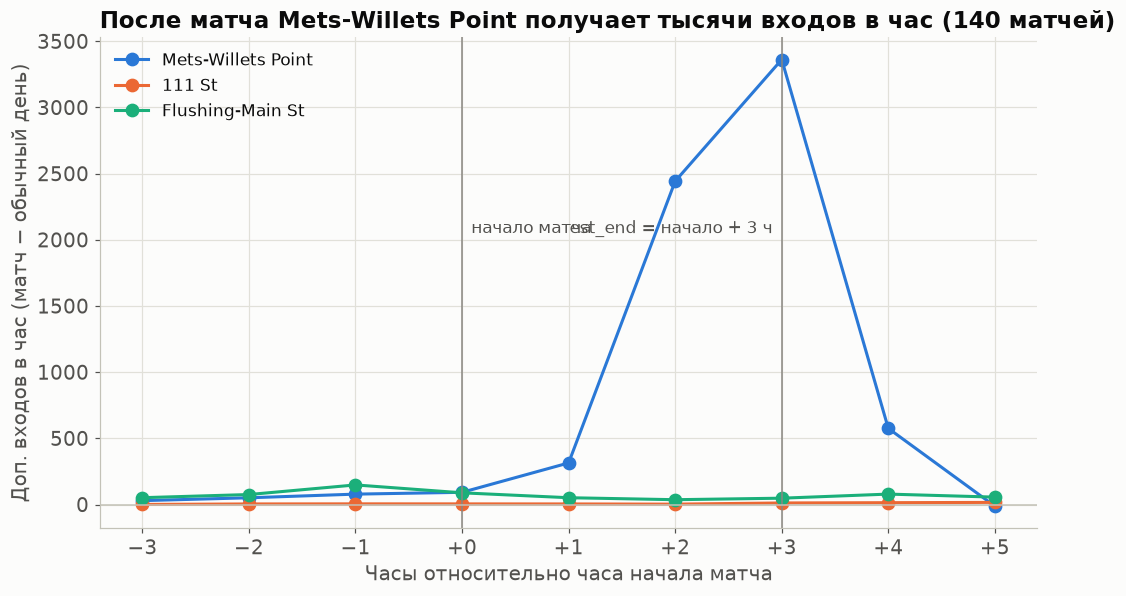

Mets-Willets Point: пик +3,362 входов/ч в час k = +3 (×25 к обычному дню); пик в час est_end у 64% матчей, на час раньше — у 31%; в час фактического окончания — у 69% (медиана окончания — через 3.0 ч после часа начала). До матча: 448 +53/ч, Flushing +92/ч, 61 St-Woodside +84/ч, Манхэттен — в пределах шума (-170…+33/ч).


In [10]:
ex = eda.game_excess(d)  # все станции — чтобы проверить станции отправления до матча
p6 = (ex[ex.station_id.isin(eda.METS_STATIONS)].groupby(["station_id", "k"])
      .agg(excess=("excess", "mean"), base=("base", "mean"), entries=("entries", "mean")).reset_index())
ps = eda.peak_shift(ex)
fig, ax = plt.subplots(figsize=(11, 5.8))
for sid, c in zip(["448", "449", "447"], eda.SERIES):
    p = p6[p6.station_id == sid]
    ax.plot(p.k, p.excess, marker="o", color=c, label=short(st.at[sid, "name"]))
top_y = p6.excess.max()
for k, txt, dx, ha in ((0, "начало матча", 6, "left"), (3, "est_end = начало + 3 ч", -6, "right")):
    ax.axvline(k, color=eda.MUTED, linewidth=1)
    ax.annotate(txt, (k, top_y * 0.62), xytext=(dx, 0), textcoords="offset points", color=eda.INK2, fontsize=11, va="center", ha=ha)
ax.axhline(0, color=eda.AXIS, linewidth=1)
ax.set_xticks(range(-3, 6), [f"{k:+d}".replace("-", "−") for k in range(-3, 6)])
ax.set_xlabel("Часы относительно часа начала матча")
ax.set_ylabel("Доп. входов в час (матч − обычный день)")
ax.set_title(f"После матча Mets-Willets Point получает тысячи входов в час ({len(ps)} матчей)", loc="left")
ax.legend(loc="upper left")
eda.save(fig, "06_mets_event_profile")
plt.show()

p448 = p6[p6.station_id == "448"].set_index("k")
kp = int(p448.excess.idxmax())
sh = ps.shift_vs_est_end.value_counts(normalize=True)
sa = ps.shift_vs_actual_end.dropna().value_counts(normalize=True)
pre = ex[ex.k < 0].groupby("station_id").excess.mean()
man = pre[["610", "609", "611", "471"]]
print(f"Mets-Willets Point: пик +{p448.excess.max():,.0f} входов/ч в час k = {kp:+d} (×{p448.entries[kp] / p448.base[kp]:.0f} к обычному дню); "
      f"пик в час est_end у {sh.get(0, 0):.0%} матчей, на час раньше — у {sh.get(-1, 0):.0%}; в час фактического окончания — у {sa.get(0, 0):.0%} "
      f"(медиана окончания — через {ps.actual_k.median():.1f} ч после часа начала). До матча: 448 {pre['448']:+.0f}/ч, Flushing {pre['447']:+.0f}/ч, "
      f"61 St-Woodside {pre['456']:+.0f}/ч, Манхэттен — в пределах шума ({man.min():+.0f}…{man.max():+.0f}/ч).")

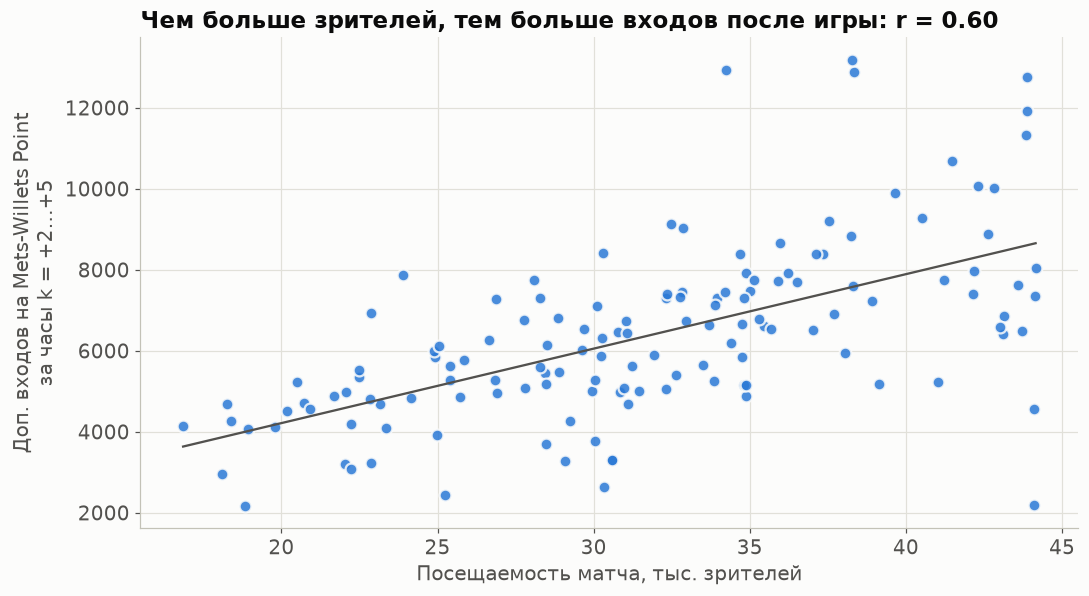

Связь с посещаемостью: r = 0.60, Спирмен 0.65 (n = 140); ≈184 доп. входов на 1 000 зрителей — около 18% зрителей уезжают от Mets-Willets Point на метро.


In [11]:
al = eda.attendance_link(ex)
t = al["table"]
fig, ax = plt.subplots(figsize=(11, 5.8))
ax.scatter(t.attendance / 1000, t.excess, s=60, color=eda.SERIES[0], edgecolor=eda.SURFACE, linewidth=1.5, alpha=0.85)
xs = np.linspace(t.attendance.min(), t.attendance.max(), 50)
ax.plot(xs / 1000, al["intercept"] + al["per_1000"] / 1000 * xs, color=eda.INK2, linewidth=1.5)
ax.set_xlabel("Посещаемость матча, тыс. зрителей")
ax.set_ylabel("Доп. входов на Mets-Willets Point\nза часы k = +2…+5")
ax.set_title(f"Чем больше зрителей, тем больше входов после игры: r = {al['pearson']:.2f}", loc="left")
eda.save(fig, "06_mets_attendance")
plt.show()

print(f"Связь с посещаемостью: r = {al['pearson']:.2f}, Спирмен {al['spearman']:.2f} (n = {al['n']}); "
      f"≈{al['per_1000']:.0f} доп. входов на 1 000 зрителей — около {al['per_1000'] / 1000:.0%} зрителей уезжают от Mets-Willets Point на метро.")

## 7. Пропуски

Пропуск — нет строки в выгрузке MTA (за два года в данных нет ни одного нулевого значения). Ночные — часы 01–05 местного времени, дневные — остальные.
Проверка: дневные — это серии подряд идущих часов на выходных, одновременно на соседних станциях (закрытия участков линии).

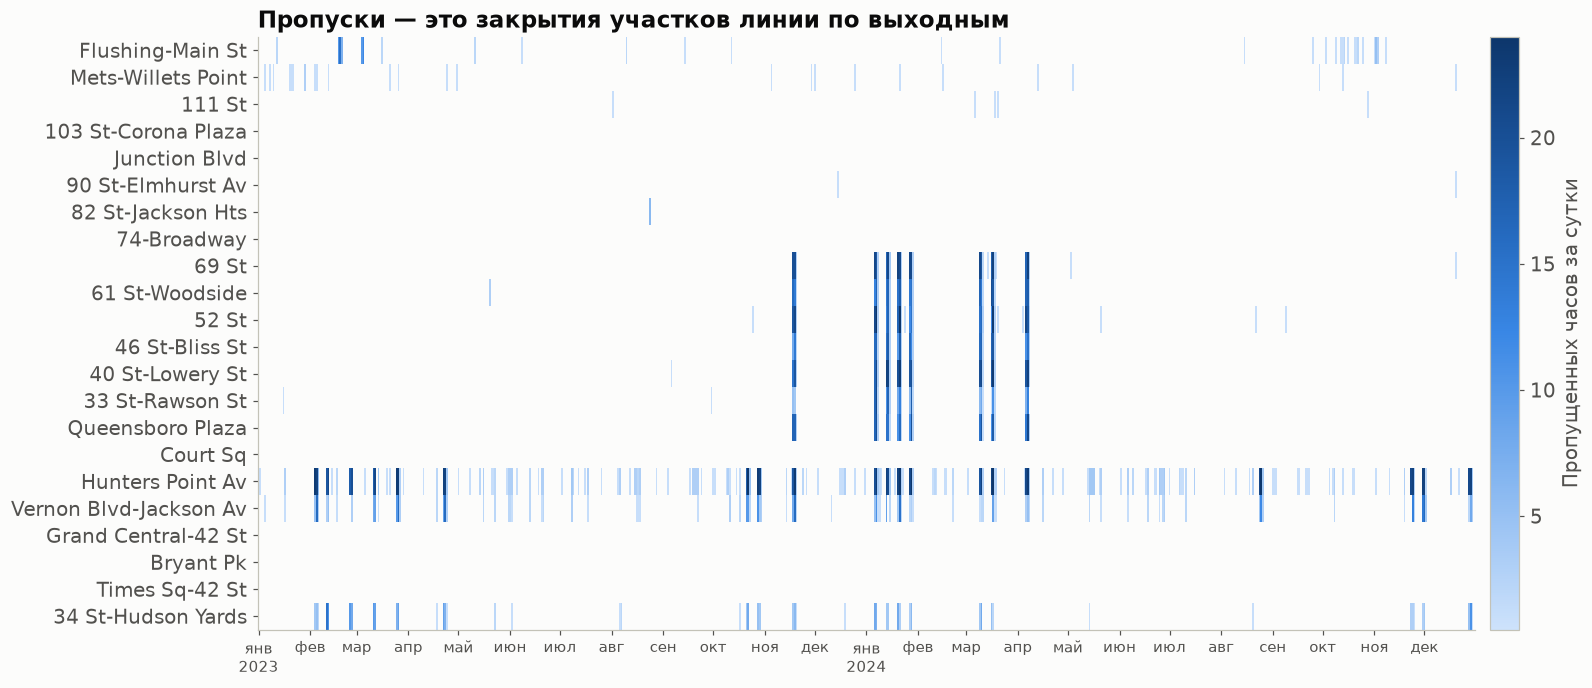

Дневные пропуски: 2,631 ч, 97% — в сб/вс; у половины из них серия ≥ 8 ч подряд, 60% часов пусты и у соседней станции — это закрытия участков линии на выходных. Ночные (01–05): 1,306 ч, а случайных нулей при таком ночном потоке ожидалось бы ~179 (Пуассон) — большинство ночных пропусков тоже не «никто не пришёл».


In [12]:
mr = eda.missing_rows(d.mta)
counts = d.mta.pivot_table(index="line_order", columns="date", values="is_missing", aggfunc="sum")
cmap = eda.blue_cmap().copy()
cmap.set_under(eda.SURFACE)
fig, ax = plt.subplots(figsize=(17, 7))
im = ax.imshow(counts.to_numpy(), aspect="auto", cmap=cmap, vmin=0.5, vmax=24, interpolation="nearest")
ax.set_yticks(range(len(counts)), [short(st.set_index("line_order").name[i]) for i in counts.index])
months = [i for i, dt in enumerate(counts.columns) if dt.day == 1]
ax.set_xticks(months, [f"{MONTHS[counts.columns[i].month - 1]}\n{counts.columns[i].year}" if counts.columns[i].month == 1
                       else MONTHS[counts.columns[i].month - 1] for i in months], fontsize=10)
ax.grid(False)
cb = fig.colorbar(im, ax=ax, pad=0.01)
cb.set_label("Пропущенных часов за сутки")
ax.set_title("Пропуски — это закрытия участков линии по выходным", loc="left")
eda.save(fig, "07_gaps_heatmap")
plt.show()

night = mr.hour.isin(eda.NIGHT_HOURS)
dayh = mr[~night]
print(f"Дневные пропуски: {len(dayh):,} ч, {(dayh.dow >= 5).mean():.0%} — в сб/вс; у половины из них серия ≥ {dayh.run_len.median():.0f} ч подряд, "
      f"{dayh.neighbor_missing.mean():.0%} часов пусты и у соседней станции — это закрытия участков линии на выходных. "
      f"Ночные (01–05): {night.sum():,} ч, а случайных нулей при таком ночном потоке ожидалось бы ~{eda.chance_zeros(d.mta, eda.NIGHT_HOURS):.0f} (Пуассон) — "
      f"большинство ночных пропусков тоже не «никто не пришёл».")

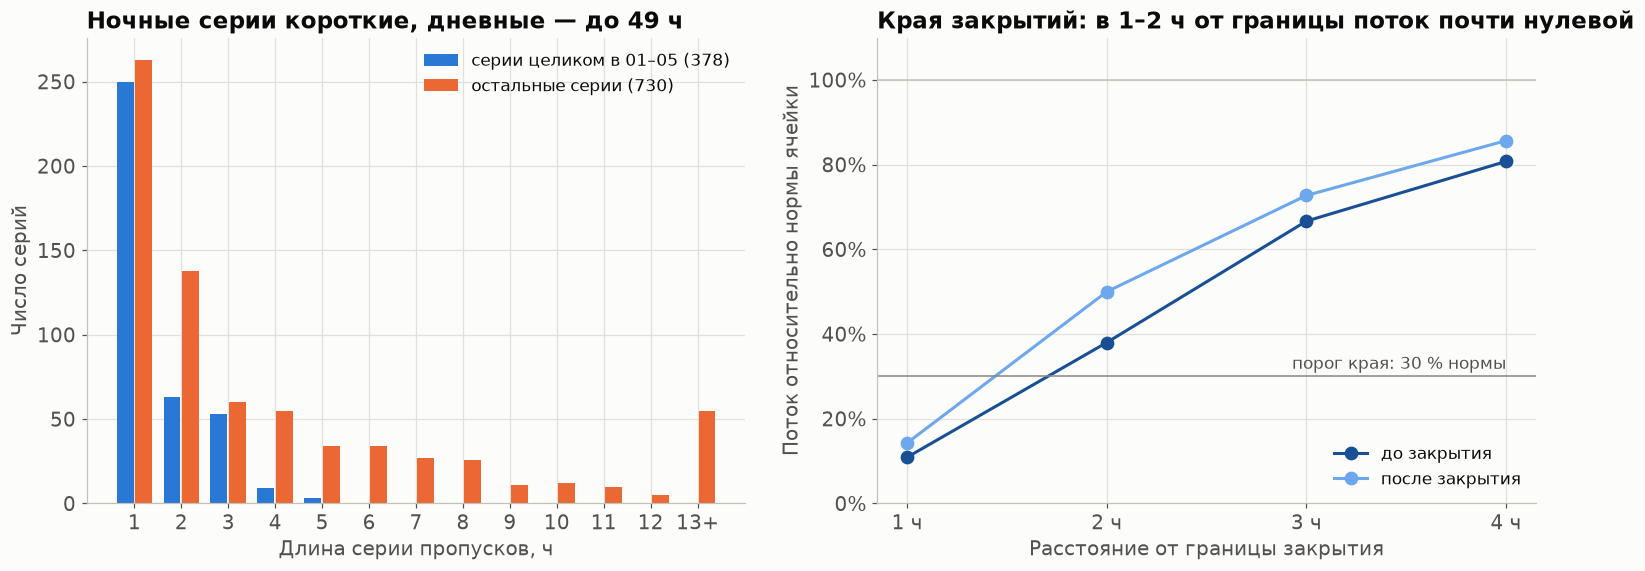

Правило: «ноль» — серия ≤ 3 ч целиком в 01–05 без пропуска у соседних станций (272 ч, заполняем 0); остальное — «закрытие» (3,665 ч) плюс «края» — прилегающие часы с потоком < 30 % нормы (1,289 ч; за 1 ч до/после закрытия поток 11%/14% нормы, за 3 ч — 67%/73%); из обучения и метрик исключаем 1.28% строк (4,954).


In [13]:
runs = eda.classify_gaps(eda.gap_runs(d.mta))
lab = eda.gap_rule(d.mta)
br = eda.boundary_ratio(d.mta, runs[runs.kind == "закрытие"]).set_index("k")
fig, (a1, a2) = plt.subplots(1, 2, figsize=(17, 5.5))
bins = np.arange(1, 14)
lens = {"серии целиком в 01–05": runs[runs.all_night].length_h, "остальные серии": runs[~runs.all_night].length_h}
for i, ((lab_, s), c) in enumerate(zip(lens.items(), eda.SERIES)):
    h = s.clip(upper=13).value_counts().reindex(bins, fill_value=0)
    a1.bar(bins + (i - 0.5) * 0.4, h, width=0.36, color=c, label=f"{lab_} ({len(s)})")
a1.set_xticks(bins, [str(b) for b in bins[:-1]] + ["13+"])
a1.set_xlabel("Длина серии пропусков, ч")
a1.set_ylabel("Число серий")
a1.set_title("Ночные серии короткие, дневные — до 49 ч", loc="left")
a1.legend(loc="upper right")
for col, c in (("до", eda.BLUE_RAMP[5]), ("после", eda.BLUE_RAMP[2])):
    a2.plot(br.index, br[col], marker="o", color=c, label=f"{col} закрытия")
a2.axhline(1, color=eda.AXIS, linewidth=1)
a2.axhline(0.3, color=eda.MUTED, linewidth=1)
a2.annotate("порог края: 30 % нормы", (4, 0.3), xytext=(0, 5), textcoords="offset points", ha="right", color=eda.INK2, fontsize=11)
a2.set_xticks(br.index, [f"{k} ч" for k in br.index])
a2.yaxis.set_major_formatter(PCT)
a2.set_ylim(0, 1.1)
a2.set_xlabel("Расстояние от границы закрытия")
a2.set_ylabel("Поток относительно нормы ячейки")
a2.set_title("Края закрытий: в 1–2 ч от границы поток почти нулевой", loc="left")
a2.legend(loc="lower right")
eda.save(fig, "07_gap_rule")
plt.show()

cnt = lab.value_counts()
excl = cnt.get("закрытие", 0) + cnt.get("край закрытия", 0)
print(f"Правило: «ноль» — серия ≤ 3 ч целиком в 01–05 без пропуска у соседних станций ({cnt['ноль']} ч, заполняем 0); остальное — «закрытие» ({cnt['закрытие']:,} ч) "
      f"плюс «края» — прилегающие часы с потоком < 30 % нормы ({cnt['край закрытия']:,} ч; за 1 ч до/после закрытия поток {br.loc[1, 'до']:.0%}/{br.loc[1, 'после']:.0%} нормы, "
      f"за 3 ч — {br.loc[3, 'до']:.0%}/{br.loc[3, 'после']:.0%}); из обучения и метрик исключаем {excl / len(d.mta):.2%} строк ({excl:,}).")

## 8. Пересадочные комплексы против обычных

Профили будних дней (доля суток) и шум слота. Сравнение и по всем станциям, и только по Квинсу — чтобы отделить эффект пересадки от эффекта Манхэттена.

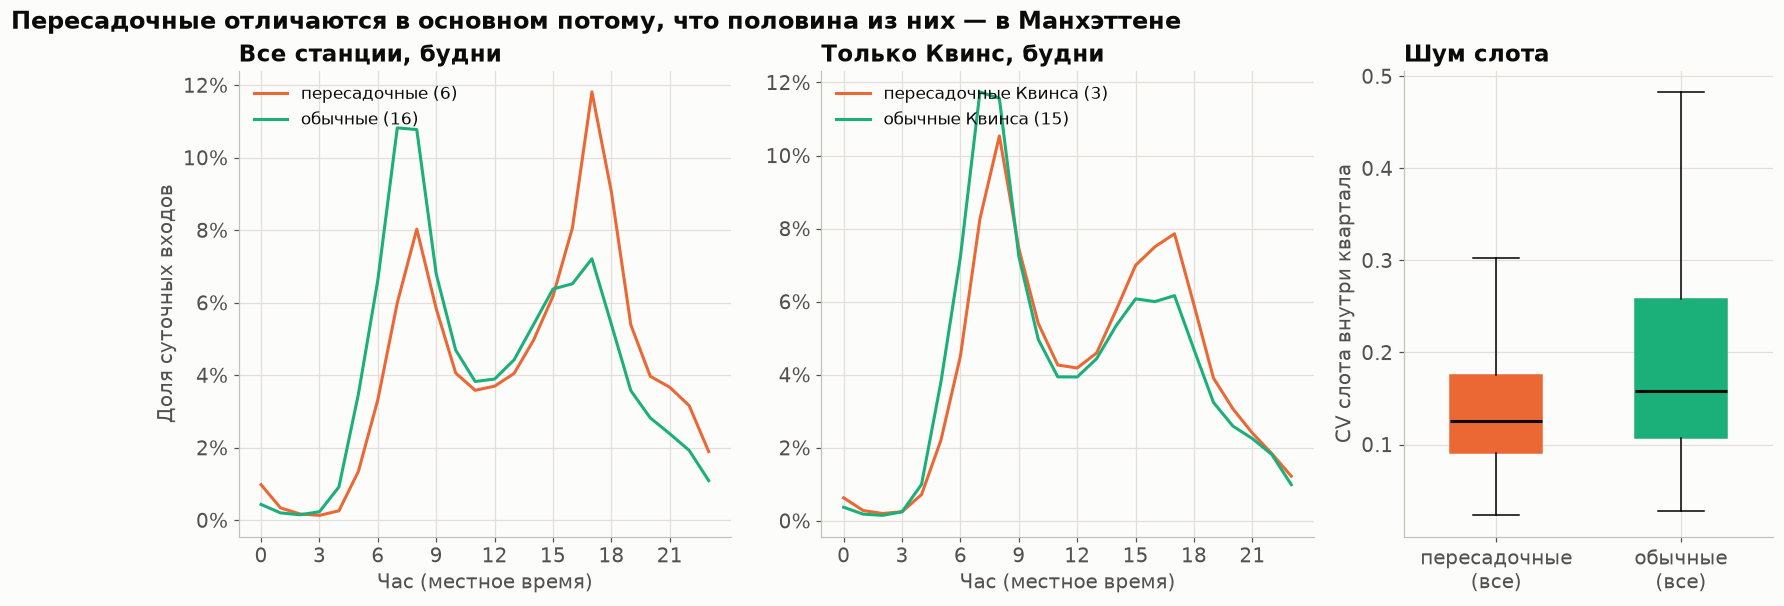

Будни: профили пересадочных и обычных расходятся на 17% суточного потока, в пределах Квинса — на 9%; утро/вечер в Квинсе ×1.34 у пересадочных против ×1.90 у обычных; шум у пересадочных ниже: медианный CV слота 0.126 против 0.158 (в Квинсе 0.132 против 0.153).


In [14]:
tc = eda.transfer_compare(d.mta)
nf = eda.noise_frame(d.mta, d.holidays)
cv = eda.slot_cv(nf)
tr_c, reg_c = eda.SERIES[1], eda.SERIES[2]
fig, axes = plt.subplots(1, 3, figsize=(18, 5.5), gridspec_kw={"width_ratios": [1, 1, 0.75]})
for ax, (a, b, title) in zip(axes[:2], [("пересадочные (6)", "обычные (16)", "Все станции, будни"),
                                          ("пересадочные Квинса (3)", "обычные Квинса (15)", "Только Квинс, будни")]):
    for kind, c in ((a, tr_c), (b, reg_c)):
        p = tc[(tc.kind == kind) & (tc.day_type == "будни")]
        ax.plot(p.hour, p.share, color=c, label=kind)
    ax.set_xticks(range(0, 24, 3))
    ax.set_xlabel("Час (местное время)")
    ax.yaxis.set_major_formatter(PCT)
    ax.set_title(title, loc="left")
    ax.legend(loc="upper left")
axes[0].set_ylabel("Доля суточных входов")
groups = {"пересадочные\n(все)": cv.is_transfer_complex, "обычные\n(все)": ~cv.is_transfer_complex}
bp = axes[2].boxplot([cv[m].cv for m in groups.values()], tick_labels=list(groups), showfliers=False, patch_artist=True, widths=0.5,
                     medianprops={"color": eda.INK, "linewidth": 2})
for patch, c in zip(bp["boxes"], (tr_c, reg_c)):
    patch.set_facecolor(c)
    patch.set_edgecolor(c)
axes[2].set_ylabel("CV слота внутри квартала")
axes[2].set_title("Шум слота", loc="left")
fig.suptitle("Пересадочные отличаются в основном потому, что половина из них — в Манхэттене",
             x=0.01, ha="left", fontsize=16, fontweight="bold")
eda.save(fig, "08_transfer_vs_regular")
plt.show()

tvd_all = eda.profile_distance(tc, "пересадочные (6)", "обычные (16)")
tvd_q = eda.profile_distance(tc, "пересадочные Квинса (3)", "обычные Квинса (15)")
pk = pd.concat([eda.peak_ratios(d.mta[m].assign(kind=k), "kind") for k, m in eda.transfer_kinds(d.mta).items()])
pk = pk[pk.day_type == "будни"].set_index("kind").ratio
cvm = {k: cv[m].cv.median() for k, m in eda.transfer_kinds(cv).items()}
print(f"Будни: профили пересадочных и обычных расходятся на {tvd_all['будни']:.0%} суточного потока, в пределах Квинса — на {tvd_q['будни']:.0%}; "
      f"утро/вечер в Квинсе ×{pk['пересадочные Квинса (3)']:.2f} у пересадочных против ×{pk['обычные Квинса (15)']:.2f} у обычных; "
      f"шум у пересадочных ниже: медианный CV слота {cvm['пересадочные (6)']:.3f} против {cvm['обычные (16)']:.3f} "
      f"(в Квинсе {cvm['пересадочные Квинса (3)']:.3f} против {cvm['обычные Квинса (15)']:.3f}).")

## 9. Шум

Коэффициент вариации слота «станция × час × тип дня» внутри квартала (без тренда и сезона) и отклонение каждого значения
от медианы того же слота за предыдущие 8 недель — это бейзлайн из раздела 6 ТЗ. Рабочие часы обычных дней, без праздников и недели 24.12–01.01.

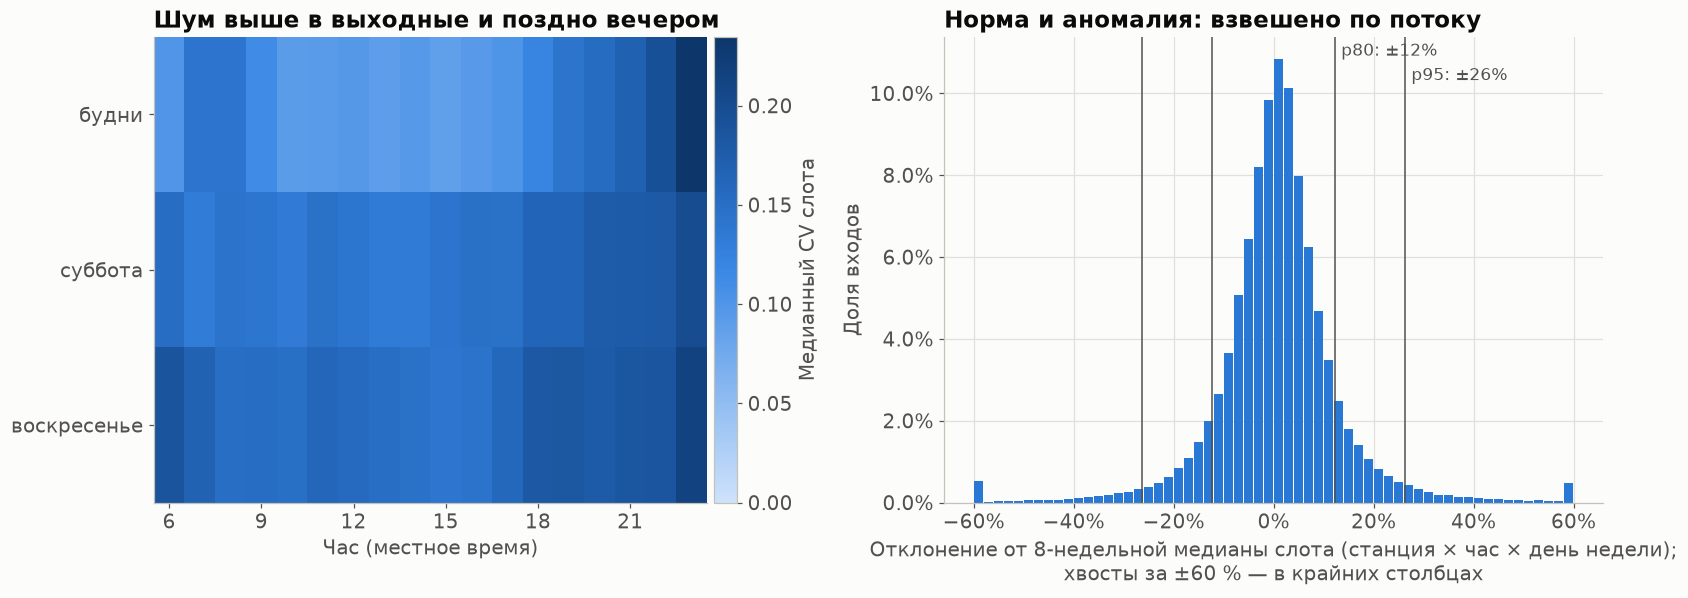

CV слота внутри квартала: медиана 0.15. Отклонение от 8-недельной нормы (взвешено по потоку): медиана 5%, p80 12%, p95 26% (без взвешивания p80 19%, p95 44% — мелкие станции шумнее); норма по дню недели вместо типа дня снижает p80 с 20.4% до 18.7%. Норма — ±12%, аномалия — от ±26%.


In [15]:
dv = eda.rolling_deviation(nf, "dow")
dvt = eda.rolling_deviation(nf, "day_type")
heat = cv.groupby(["day_type", "hour"], observed=True).cv.median().unstack().loc[["будни", "суббота", "воскресенье"]]
adev, wgt = dv.dev.abs(), dv.base
w50, w80, w95 = (eda.weighted_quantile(adev, wgt, q) for q in (0.5, 0.8, 0.95))
fig, (a1, a2) = plt.subplots(1, 2, figsize=(17, 5.5), gridspec_kw={"width_ratios": [1, 1]})
im = a1.imshow(heat.to_numpy(), aspect="auto", cmap=eda.blue_cmap(), vmin=0)
a1.set_yticks(range(3), heat.index)
a1.set_xticks(range(0, len(heat.columns), 3), heat.columns[::3])
a1.set_xlabel("Час (местное время)")
a1.grid(False)
cb = fig.colorbar(im, ax=a1, pad=0.01)
cb.set_label("Медианный CV слота")
a1.set_title("Шум выше в выходные и поздно вечером", loc="left")
a2.hist(dv.dev.clip(-0.6, 0.6), bins=np.linspace(-0.6, 0.6, 61), weights=wgt / wgt.sum(), color=eda.SERIES[0], rwidth=0.9)
for q, v in (("p80", w80), ("p95", w95)):
    for sgn in (-1, 1):
        a2.axvline(sgn * v, color=eda.INK2, linewidth=1)
    a2.annotate(f"{q}: ±{v:.0%}", (v, a2.get_ylim()[1]), xytext=(4, -4 - 16 * (q == "p95")), textcoords="offset points",
                color=eda.INK2, fontsize=11, va="top")
a2.xaxis.set_major_formatter(PCT)
a2.yaxis.set_major_formatter(PercentFormatter(1.0, decimals=1))
a2.set_xlabel("Отклонение от 8-недельной медианы слота (станция × час × день недели);\nхвосты за ±60 % — в крайних столбцах")
a2.set_ylabel("Доля входов")
a2.set_title("Норма и аномалия: взвешено по потоку", loc="left")
eda.save(fig, "09_noise")
plt.show()

at = dvt.dev.abs()
print(f"CV слота внутри квартала: медиана {cv.cv.median():.2f}. Отклонение от 8-недельной нормы (взвешено по потоку): медиана {w50:.0%}, p80 {w80:.0%}, p95 {w95:.0%} "
      f"(без взвешивания p80 {adev.quantile(0.8):.0%}, p95 {adev.quantile(0.95):.0%} — мелкие станции шумнее); норма по дню недели вместо типа дня "
      f"снижает p80 с {at.quantile(0.8):.1%} до {adev.quantile(0.8):.1%}. Норма — ±{w80:.0%}, аномалия — от ±{w95:.0%}.")